# Fidelidad vocacional — Universidad de Antioquia
## Redes Neuronales: MLP, Arquitectura Multimodal, Regularización y Transfer Learning

## Players

- Angel Rey - 1020398607 - <angel.rey@udea.edu.co>
- Camilo Valencia - 1036666867 - <camilo.valencia6@udea.edu.co>

## 1. Descripción y contextualización del problema

La Universidad de Antioquia admite miles de estudiantes cada semestre a programas de pregrado, tecnología y técnico profesional. Una proporción significativa no llega a graduarse del programa al cual fue admitida, ya sea por deserción, cambio de programa o retiro. Identificar patrones asociados a este fenómeno, a partir de información disponible al momento de la inscripción, es relevante tanto para la gestión académica como para el diseño de políticas de acompañamiento estudiantil.

**Tarea de Machine Learning:** clasificación binaria supervisada.
- **Entrada:** características disponibles al momento de la inscripción (perfil personal, origen geográfico, colegio de procedencia, programa académico).
- **Salida:** probabilidad de que el estudiante se gradúe del mismo programa al que se inscribió.
- **Restricción temporal:** solo se usan inscripciones anteriores al semestre `20192`, para garantizar que los estudiantes hayan tenido tiempo real de graduarse.


## 2. Descripción de la base de datos

| Archivo | Descripción |
|---|---|
| `matriculados.csv` | Una fila por estudiante-inscripción. Variables de perfil al momento de admisión (2,708,438 filas, 69 columnas). |
| `graduados.csv` | Registro de egresados con código de programa y semestre de grado (98,595 filas, 24 columnas). |

**Variable objetivo:** `target = 1` si el estudiante aparece en `graduados` con el mismo `cod_progacad`; `0` en caso contrario.

**Features — 17 variables agrupadas según su naturaleza:**

| Grupo | Variables | Encoding |
|---|---|---|
| Perfil personal y geográfico | `sexo`, `estado civil`, `tipo admisión`, `región`, `depto residencia`, `estrato`, `admisiones previas` | One-hot / escalado |
| Perfil académico e institucional | `área conocimiento`, `nivel`, `modalidad`, `sede`, `naturaleza/localización/tipo/jornada colegio` | One-hot / escalado |
| Código de programa | `cod_progacad_inscrito` (431 valores únicos) | Embedding (dim=8) |

El **one-hot encoding** evita que la red interprete diferencias de código como distancias numéricas. El **embedding** para `cod_progacad_inscrito` permite que la red aprenda una representación propia de cada programa durante el entrenamiento.

**Desbalance de clases:** la proporción de graduados (~30%) vs no-graduados (~70%) requiere estrategia de balanceo; se aplica `RandomOverSampler` exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información.


## 3. Diseño experimental

**Pipeline común a todos los experimentos:**
1. Limpieza y filtros (admitidos, tipos de programa, corte temporal `20192`)
2. Construcción del target (cruce `matriculados` × `graduados`)
3. Encoding: one-hot para categóricas, embedding para `cod_progacad_inscrito`, escalado estándar para numéricas
4. Detección de outliers con `LocalOutlierFactor` (contamination=5%)
5. Split estratificado 70% train / 15% val / 15% test con conjunto de validación **fijo** (`random_state=42`)
6. Oversampling solo sobre train (`RandomOverSampler`)

**Experimentos:**

| ID | Arquitectura | Concepto clave |
|---|---|---|
| **Exp A** | MLP simple (82→50→30→1) | Baseline: red densa plana |
| **Exp B** | Multimodal: MLP + Embedding de programa | Representación separada para variable categórica de alta cardinalidad |
| **Exp C** | Multimodal + BatchNorm + Dropout + Conexiones Residuales | Regularización y redes profundas |
| **Exp D** | Transfer Learning: Autoencoder pre-entrenado → clasificador | Aprendizaje no supervisado de representaciones + fine-tuning |

**Métricas de evaluación:**
- **AUC-ROC** (métrica principal): mide la capacidad discriminativa del modelo independientemente del umbral.
- **Accuracy**: porcentaje de predicciones correctas a umbral 0.5.
- **Classification report**: precisión, recall y F1 por clase.
- **Curva de loss** train vs. validación: permite detectar sobreajuste o convergencia prematura.


## 4. Librerías y semillas de reproducibilidad

In [ ]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (Dense, Flatten, Input, Embedding,
                                     BatchNormalization, Dropout,
                                     Add, Concatenate, Activation)
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (roc_auc_score, accuracy_score, roc_curve,
                              ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import RandomOverSampler

# ─── Semillas para reproducibilidad ───────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED']      = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print("TensorFlow:", tf.__version__)
print(f"Seeds fijadas: SEED={SEED}")


TensorFlow: 2.19.0
Seeds fijadas: SEED=42


## 5. Carga de datos

In [ ]:
!pip install gdown -q

import gdown

gdown.download(id='1xCC_E2kLhOFdcJFI3sgSEOKgXmZwvjGy', output='matriculados.csv', quiet=False)
gdown.download(id='13gR8UfCMpXCHTT8sE03kBSARzx6sDnzM',    output='graduados.csv',    quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1xCC_E2kLhOFdcJFI3sgSEOKgXmZwvjGy
From (redirected): https://drive.google.com/uc?id=1xCC_E2kLhOFdcJFI3sgSEOKgXmZwvjGy&confirm=t&uuid=3f80fc2c-70d6-4873-b014-ef337575ea01
To: /content/matriculados.csv
100%|██████████| 1.41G/1.41G [00:10<00:00, 134MB/s]
Downloading...
From: https://drive.google.com/uc?id=13gR8UfCMpXCHTT8sE03kBSARzx6sDnzM
To: /content/graduados.csv
100%|██████████| 21.2M/21.2M [00:00<00:00, 103MB/s]


'graduados.csv'

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

graduados    = pd.read_csv('graduados.csv')
matriculados = pd.read_csv('matriculados.csv')

print("graduados:   ", graduados.shape)
print("matriculados:", matriculados.shape)


graduados:    (98595, 24)
matriculados: (2708438, 69)


## 6. Preparación del dataset

In [ ]:
# limpieza y filtros
mask = graduados['id_unico_estudiante'].astype(str).str.startswith('Licencia')
graduados = graduados[~mask].copy()
graduados['cod_progacad_graduado'] = pd.to_numeric(
    graduados['cod_progacad_graduado'], errors='coerce').astype('Int64')

mask = matriculados['id_unico_estudiante'].astype(str).str.startswith('Licencia')
matriculados = matriculados[~mask & matriculados['id_unico_estudiante'].notna()].copy()

TIPOS = ['PREGRADO', 'TECNOLOGO', 'TECNICO_P']
matriculados['tipo_progacad_inscrito'] = matriculados['tipo_progacad_inscrito'].astype(str).str.strip().str.upper()
matriculados = matriculados[
    (matriculados['admitido_inscrito'] == 'SI') &
    (matriculados['tipo_progacad_inscrito'].isin(TIPOS))
].copy()

CORTE = '20192'
matriculados['semestre_a_iniciar_inscrito'] = matriculados['semestre_a_iniciar_inscrito'].astype(str).str.strip()
df = matriculados[matriculados['semestre_a_iniciar_inscrito'] <= CORTE].copy()

print("Admitidos antes del corte:", len(df))
print(df['tipo_progacad_inscrito'].value_counts())


Admitidos antes del corte: 134703
tipo_progacad_inscrito
PREGRADO    134703
Name: count, dtype: int64


In [ ]:
# construcción del target
grad_lookup = graduados[['id_unico_estudiante','cod_progacad_graduado']].drop_duplicates()

df = df.merge(
    grad_lookup.rename(columns={'cod_progacad_graduado': 'cod_prog_grad'}),
    on='id_unico_estudiante', how='left'
)
df['cod_progacad_inscrito'] = pd.to_numeric(df['cod_progacad_inscrito'], errors='coerce')
df['target'] = (df['cod_progacad_inscrito'] == df['cod_prog_grad'].fillna(-1)).astype(int)
df = (df.sort_values('target', ascending=False)
        .drop_duplicates(subset='id_unico_estudiante', keep='first')
        .drop(columns='cod_prog_grad')
        .reset_index(drop=True))

print("Dataset:", len(df), "estudiantes")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Dataset: 120409 estudiantes
target
0    80777
1    39632
Name: count, dtype: int64
target
0    67.1%
1    32.9%
Name: proportion, dtype: object


In [ ]:
# encoding
cat_ohe = ['sexo_inscrito','est_civil_inscrito','tipo_admision_inscrito',
           'nom_region_res_inscrito','area_cmto_inscrito',
           'nivel_academ2_inscrito','modalidad_progacad_inscrito','sede_inscrito',
           'colegio_naturalejur_inscrito','colegio_localiz_inscrito']
col_emb  = 'cod_progacad_inscrito'
num_cols = ['estrat_socioe_inscrito','total_admis_pregr_inscrito',
            'cod_depart_res_inscrito',
            'colegio_tipo_inscrito','colegio_naturale_inscrito','colegio_jornada_inscrito']

X_raw = df[cat_ohe + [col_emb] + num_cols].copy()

for col in cat_ohe:
    X_raw[col] = X_raw[col].fillna('DESCONOCIDO').astype(str).str.upper().str.strip()
for col in num_cols:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce').fillna(X_raw[col].median())

# índice entero para la capa Embedding
le_prog = LabelEncoder()
X_raw[col_emb] = le_prog.fit_transform(X_raw[col_emb].fillna('DESCONOCIDO').astype(str))
n_programas = len(le_prog.classes_)

# one-hot para el resto de categóricas
ohe   = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe = ohe.fit_transform(X_raw[cat_ohe])
X_num = X_raw[num_cols].values.astype(float)
X_prog = X_raw[col_emb].values.astype(int)
y     = df['target'].values

print("One-hot features:", X_ohe.shape[1], " (de", len(cat_ohe), "variables)")
print("Numéricas        :", X_num.shape[1])
print("Embedding        : cod_progacad —", n_programas, "programas únicos")
print("Total filas      :", len(y))


One-hot features: 76  (de 10 variables)
Numéricas        : 6
Embedding        : cod_progacad — 431 programas únicos
Total filas      : 120409


In [ ]:
# outliers
lof = LocalOutlierFactor(n_neighbors=13, contamination=0.05)
mask_lof = lof.fit_predict(np.hstack([X_num, X_prog.reshape(-1,1)])) == -1
print("Outliers detectados:", mask_lof.sum(), f"({mask_lof.mean()*100:.1f}%)")

X_ohe  = X_ohe[~mask_lof]
X_num  = X_num[~mask_lof]
X_prog = X_prog[~mask_lof]
y      = y[~mask_lof]
print("Dataset final:", len(y), "filas")


Outliers detectados: 5627 (4.7%)
Dataset final: 114782 filas


In [ ]:
# split 70/15/15 con validación fija
idx = np.arange(len(y))
idx_temp, idx_test = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=y)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.15/0.85, random_state=SEED, stratify=y[idx_temp])

# oversampling solo sobre train
ros = RandomOverSampler(random_state=SEED)
idx_train_bal, y_train = ros.fit_resample(idx_train.reshape(-1,1), y[idx_train])
idx_train_bal = idx_train_bal.ravel()

# escalado numérico (fit solo sobre train)
scaler = StandardScaler()
X_num_tr  = scaler.fit_transform(X_num[idx_train_bal])
X_num_val = scaler.transform(X_num[idx_val])
X_num_te  = scaler.transform(X_num[idx_test])

# input_features: OHE + numéricas escaladas (mismo vector para todos los experimentos)
X_train = np.hstack([X_ohe[idx_train_bal], X_num_tr])
X_val   = np.hstack([X_ohe[idx_val],       X_num_val])
X_test  = np.hstack([X_ohe[idx_test],      X_num_te])

# input_programa: índice de programa para la capa Embedding
X_prog_train = X_prog[idx_train_bal]
X_prog_val   = X_prog[idx_val]
X_prog_test  = X_prog[idx_test]

y_val  = y[idx_val]
y_test = y[idx_test]

print("Train:", X_train.shape, "| pos:", y_train.sum(), "| neg:", (y_train==0).sum())
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print()
print("dimension de input_features  :", X_train.shape[1])
print("dimension de input_programa  : 1 (índice entero → Embedding de dim 8)")


Train: (107698, 82) | pos: 53849 | neg: 53849
Val:   (17218, 82)
Test:  (17218, 82)

dimension de input_features  : 82
dimension de input_programa  : 1 (índice entero → Embedding de dim 8)


## 7. Experimentos

### Exp A — MLP simple (Baseline)

`get_model_A` define una red densa que recibe `input_features` con todas las features OHE+numéricas y las procesa en capas densas hasta la salida. Sirve como línea base para comparar el efecto de arquitecturas más sofisticadas.

Número de conexiones:

    INPUT(82) → LAYER 1(50):    82×50  + 50  (bias) =  4,150
    LAYER 1(50) → LAYER 2(30):  50×30  + 30  (bias) =  1,530
    LAYER 2(30) → OUTPUT(1):    30×1   +  1  (bias) =     31
                                                TOTAL =  5,711


In [ ]:
def get_model_A(input_dim, s1, s2):
    clear_session()
    inp = Input(shape=(input_dim,), name="input_features")
    x   = Dense(s1, activation='relu')(inp)
    x   = Dense(s2, activation='relu')(x)
    out = Dense(1,  activation='sigmoid')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_A = get_model_A(input_dim=X_train.shape[1], s1=50, s2=30)
model_A.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         4,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,711 (22.31 KB)

 Trainable params: 5,711 (22.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')

hist_A = model_A.fit(
    X_train, y_train,
    epochs=100, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[es]
)


Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6510 - loss: 0.6162 - val_accuracy: 0.6370 - val_loss: 0.6157
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6673 - loss: 0.5970 - val_accuracy: 0.6413 - val_loss: 0.6106
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6713 - loss: 0.5927 - val_accuracy: 0.6437 - val_loss: 0.6076
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6735 - loss: 0.5903 - val_accuracy: 0.6446 - val_loss: 0.6053
Epoch 5/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6748 - loss: 0.5886 - val_accuracy: 0.6457 - val_loss: 0.6039
Epoch 6/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6760 - loss: 0.5871 - val_accuracy: 0.6454 - val_loss: 0.6038
Epoch 7/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6767 - loss: 0.5859 - val_accuracy: 0.6442 - val_loss: 0.6039
Epoch 8/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6778 - loss: 0.5849 - val_accu

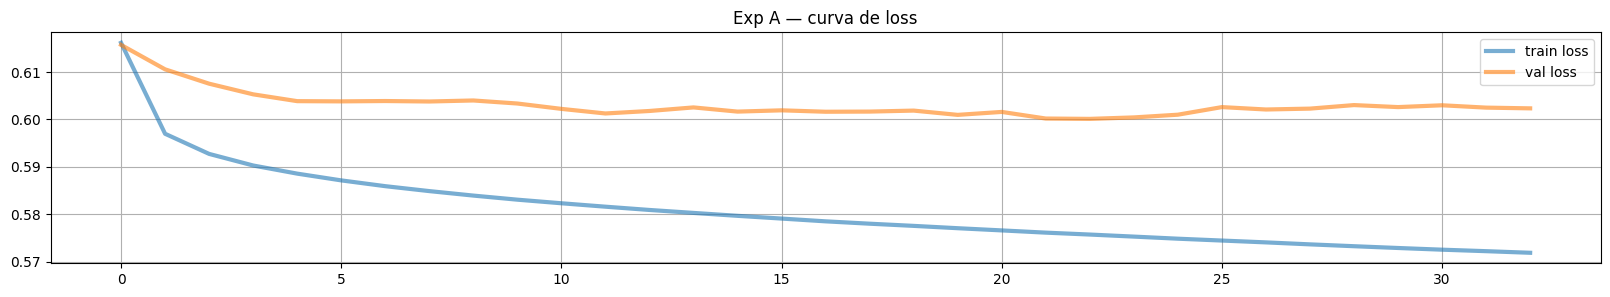

In [ ]:
plt.figure(figsize=(20, 3))
plt.plot(hist_A.history['loss'],     lw=3, alpha=.6, label='train loss')
plt.plot(hist_A.history['val_loss'], lw=3, alpha=.6, label='val loss')
plt.title('Exp A — curva de loss'); plt.grid(); plt.legend()


In [ ]:
preds_train_A = (model_A.predict(X_train, verbose=0).ravel() >= 0.5).astype(int)
proba_A       = model_A.predict(X_test,  verbose=0).ravel()
preds_A       = (proba_A >= 0.5).astype(int)

print("Exp A — MLP simple")
print("  accuracy train : %.4f" % np.mean(preds_train_A == y_train))
print("  accuracy test  : %.4f" % accuracy_score(y_test, preds_A))
print("  AUC-ROC  test  : %.4f" % roc_auc_score(y_test, proba_A))


Exp A — MLP simple
  accuracy train : 0.6872
  accuracy test  : 0.6418
  AUC-ROC  test  : 0.7352


### Exp B — Red Multimodal con Embedding de programa

`get_model_B` recibe dos entradas: `input_features` (vector OHE+numéricas) y `input_programa` (el índice del programa académico). El embedding aprendido representa cada uno de los 431 programas como un vector denso de 8 dimensiones. Este vector se concatena con la representación aprendida por la rama principal justo antes de la salida, permitiendo al modelo capturar relaciones específicas por carrera.

Número de conexiones:

    INPUT(82) → LAYER 1(50):        82×50  + 50  (bias) =  4,150
    LAYER 1(50) → LAYER 2(30):      50×30  + 30  (bias) =  1,530
    Embedding(431, 8):              431×8               =  3,448
    (LAYER2 + EMB)(38) → OUTPUT:    38×1   +  1  (bias) =     39
                                                  TOTAL =  9,167


In [ ]:
class Concat(tf.keras.layers.Layer):
    def call(self, layers):
        return tf.concat(layers, axis=1)

def get_model_B(input_dim, n_prog, emb_dim, s1, s2):
    clear_session()

    inp1 = Input(shape=(input_dim,), name="input_features")
    l1   = Dense(s1, activation='relu', name="dense1")(inp1)
    l2   = Dense(s2, activation='relu', name="dense2")(l1)

    inp2 = Input(shape=(1,), name="input_programa")
    emb  = Embedding(input_dim=n_prog, output_dim=emb_dim, name="emb_programa")(inp2)
    emb  = Flatten()(emb)

    cc     = Concat()([l2, emb])
    output = Dense(1, activation='sigmoid', name="output")(cc)

    model = Model(inputs=[inp1, inp2], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_B = get_model_B(input_dim=X_train.shape[1], n_prog=n_programas, emb_dim=8, s1=50, s2=30)
model_B.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 82)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_programa      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 50)        │      4,150 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_programa        │ (None, 1, 8)      │      3,448 │ input_programa[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 30)        │      1,530 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ emb_programa[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat (Concat)     │ (None, 38)        │          0 │ dense2[0][0],     │
│                     │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         39 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,167 (35.81 KB)

 Trainable params: 9,167 (35.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')

hist_B = model_B.fit(
    [X_train, X_prog_train], y_train,
    epochs=100, batch_size=256,
    validation_data=([X_val, X_prog_val], y_val),
    callbacks=[es]
)


Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6716 - loss: 0.5969 - val_accuracy: 0.6795 - val_loss: 0.5783
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6983 - loss: 0.5665 - val_accuracy: 0.6830 - val_loss: 0.5727
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7017 - loss: 0.5626 - val_accuracy: 0.6844 - val_loss: 0.5714
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7030 - loss: 0.5605 - val_accuracy: 0.6853 - val_loss: 0.5693
Epoch 5/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7041 - loss: 0.5590 - val_accuracy: 0.6857 - val_loss: 0.5688
Epoch 6/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7052 - loss: 0.5578 - val_accuracy: 0.6842 - val_loss: 0.5682
Epoch 7/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7063 - loss: 0.5568 - val_accuracy: 0.6844 - val_loss: 0.5676
Epoch 8/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7070 - loss: 0.5557 - val_accu

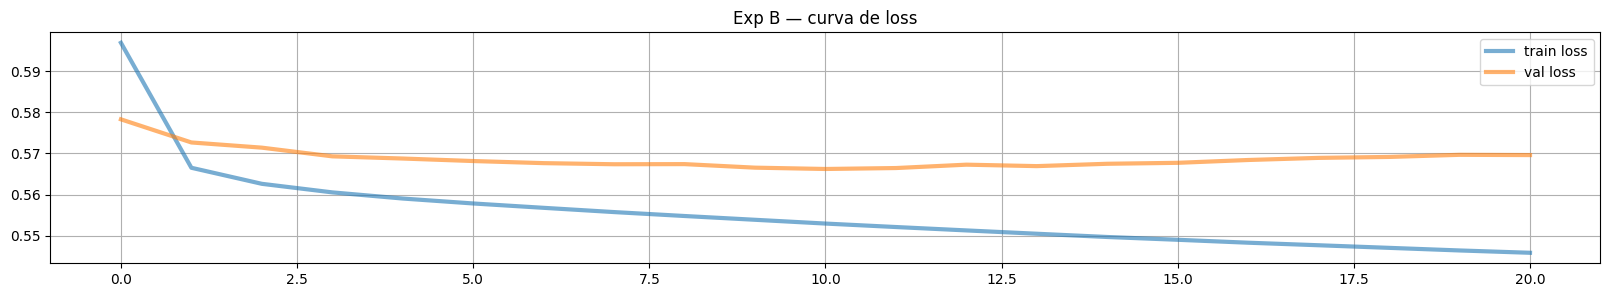

In [ ]:
plt.figure(figsize=(20, 3))
plt.plot(hist_B.history['loss'],     lw=3, alpha=.6, label='train loss')
plt.plot(hist_B.history['val_loss'], lw=3, alpha=.6, label='val loss')
plt.title('Exp B — curva de loss'); plt.grid(); plt.legend()


In [ ]:
preds_train_B = (model_B.predict([X_train, X_prog_train], verbose=0).ravel() >= 0.5).astype(int)
proba_B       = model_B.predict([X_test, X_prog_test],   verbose=0).ravel()
preds_B       = (proba_B >= 0.5).astype(int)

print("Exp B — Multimodal + Embedding")
print("  accuracy train : %.4f" % np.mean(preds_train_B == y_train))
print("  accuracy test  : %.4f" % accuracy_score(y_test, preds_B))
print("  AUC-ROC  test  : %.4f" % roc_auc_score(y_test, proba_B))


Exp B — Multimodal + Embedding
  accuracy train : 0.7104
  accuracy test  : 0.6851
  AUC-ROC  test  : 0.7700


### Exp C — Multimodal con Batch Normalization, Dropout y Conexiones Residuales

`get_model_C` extiende la arquitectura del Experimento B con tres técnicas de regularización y profundidad:

1. **Batch Normalization**: normaliza las activaciones de cada capa (media≈0, var≈1 dentro del mini-batch), lo que acelera la convergencia, reduce la dependencia de la inicialización de pesos y actúa como regularizador implícito.

2. **Dropout** (p=0.3): en cada paso de entrenamiento desactiva aleatoriamente el 30% de las neuronas de cada capa. Esto fuerza al modelo a aprender representaciones redundantes, reduciendo el sobreajuste.

3. **Conexiones residuales (skip connections)**: en el segundo bloque residual, la entrada del bloque se suma directamente a su salida (`h_out = F(h) + h`). Esto permite que el gradiente fluya directamente hacia atrás sin degradarse, facilitando el entrenamiento de redes más profundas y evitando el problema del gradiente evanescente.

La rama de **Embedding** para `cod_progacad_inscrito` se mantiene del Experimento B.

Número de conexiones (aprox.):

    INPUT(82) → Dense(128) + BN:             82×128 + 128 =  10,624
    Dense(64)  + BN (bloque res. 1):        128×64  + 64  =   8,256
    Dense(64)  + BN (bloque res. 2 + skip):  64×64  + 64  =   4,160
    Embedding(431, 8):                       431×8         =   3,448
    Concat(64+8) → OUTPUT:                    72×1  +  1   =      73
                                                    TOTAL ≈  26,561


In [ ]:
def get_model_C(input_dim, n_prog, emb_dim=8, s1=128, s2=64, dropout_rate=0.3):
    clear_session()

    # ── Rama principal ──────────────────────────────────────────────────
    inp1 = Input(shape=(input_dim,), name="input_features")

    # Bloque de proyección inicial
    h = Dense(s1, use_bias=False)(inp1)
    h = BatchNormalization()(h)
    h = Activation('relu')(h)
    h = Dropout(dropout_rate)(h)

    # Bloque residual 1: s1 → s2
    h2 = Dense(s2, use_bias=False)(h)
    h2 = BatchNormalization()(h2)
    h2 = Activation('relu')(h2)
    h2 = Dropout(dropout_rate)(h2)

    # Bloque residual 2: s2 → s2 con skip connection
    h3 = Dense(s2, use_bias=False)(h2)
    h3 = BatchNormalization()(h3)
    h3 = Activation('relu')(h3)
    h3 = Dropout(dropout_rate)(h3)
    h3 = Add()([h2, h3])            # ← conexión residual

    # ── Rama de programa (Embedding) ────────────────────────────────────
    inp2 = Input(shape=(1,), name="input_programa")
    emb  = Embedding(input_dim=n_prog, output_dim=emb_dim, name="emb_programa")(inp2)
    emb  = Flatten()(emb)

    # ── Fusión y salida ─────────────────────────────────────────────────
    cc  = Concatenate()([h3, emb])
    out = Dense(1, activation='sigmoid', name="output")(cc)

    model = Model(inputs=[inp1, inp2], outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_C = get_model_C(input_dim=X_train.shape[1], n_prog=n_programas)
model_C.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 82)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     10,496 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,192 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,096 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_programa      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_programa        │ (None, 1, 8)      │      3,448 │ input_programa[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ emb_programa[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ add[0][0],        │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         73 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 27,329 (106.75 KB)

 Trainable params: 26,817 (104.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
es = EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss')

hist_C = model_C.fit(
    [X_train, X_prog_train], y_train,
    epochs=150, batch_size=256,
    validation_data=([X_val, X_prog_val], y_val),
    callbacks=[es]
)


Epoch 1/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6417 - loss: 0.6398 - val_accuracy: 0.6845 - val_loss: 0.5752
Epoch 2/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6889 - loss: 0.5805 - val_accuracy: 0.6927 - val_loss: 0.5659
Epoch 3/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6965 - loss: 0.5713 - val_accuracy: 0.6920 - val_loss: 0.5641
Epoch 4/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6985 - loss: 0.5684 - val_accuracy: 0.6887 - val_loss: 0.5671
Epoch 5/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6997 - loss: 0.5657 - val_accuracy: 0.6901 - val_loss: 0.5658
Epoch 6/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7006 - loss: 0.5644 - val_accuracy: 0.6906 - val_loss: 0.5613
Epoch 7/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7026 - loss: 0.5632 - val_accuracy: 0.6898 - val_loss: 0.5659
Epoch 8/150
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7009 - loss: 0.5628 - val_ac

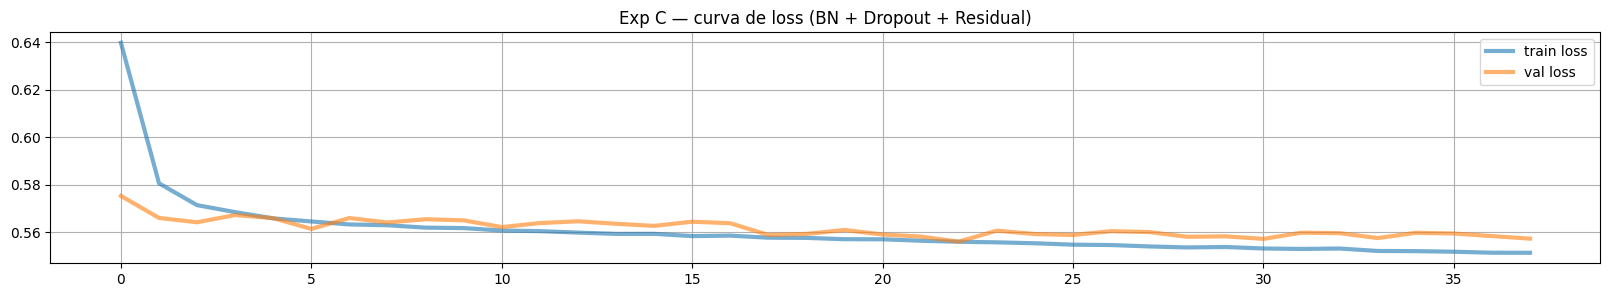

In [ ]:
plt.figure(figsize=(20, 3))
plt.plot(hist_C.history['loss'],     lw=3, alpha=.6, label='train loss')
plt.plot(hist_C.history['val_loss'], lw=3, alpha=.6, label='val loss')
plt.title('Exp C — curva de loss (BN + Dropout + Residual)'); plt.grid(); plt.legend()


In [ ]:
preds_train_C = (model_C.predict([X_train, X_prog_train], verbose=0).ravel() >= 0.5).astype(int)
proba_C       = model_C.predict([X_test, X_prog_test],   verbose=0).ravel()
preds_C       = (proba_C >= 0.5).astype(int)

print("Exp C — Multimodal + BN + Dropout + Residual")
print("  accuracy train : %.4f" % np.mean(preds_train_C == y_train))
print("  accuracy test  : %.4f" % accuracy_score(y_test, preds_C))
print("  AUC-ROC  test  : %.4f" % roc_auc_score(y_test, proba_C))


Exp C — Multimodal + BN + Dropout + Residual
  accuracy train : 0.7123
  accuracy test  : 0.6933
  AUC-ROC  test  : 0.7732


### Exp D — Transfer Learning con Autoencoder Pre-entrenado

El Experimento D aplica **transfer learning** a datos tabulares en dos fases:

---

**Fase 1 — Pre-entrenamiento no supervisado (Autoencoder)**

Se entrena un Autoencoder sobre `X_train` con el objetivo de reconstruir el vector de features original a partir de una representación comprimida de 32 dimensiones (*bottleneck*). El autoencoder **no usa el target `y`** — aprende únicamente la estructura de los datos de entrada.

La arquitectura encoder–decoder usa BatchNormalization y Dropout en todas las capas intermedias para aprender una representación robusta.

---

**Fase 2 — Transferencia y fine-tuning**

- **Paso 2a — Encoder congelado:** Se extrae el encoder del autoencoder y se congela (`trainable=False`). Se añade una capa sigmoid de clasificación sobre el bottleneck y se entrena solo esa cabeza, en lo que se denomina *feature extraction*. El encoder actúa como un extractor de características fijo.

- **Paso 2b — Fine-tuning:** Se descongela el encoder completo y se re-entrena el modelo completo con un learning rate reducido (1×10⁻⁴). Esto permite que la representación interna se ajuste sutilmente a la tarea de clasificación sin olvidar lo aprendido en la fase 1.

---

Esta estrategia emula exactamente el paradigma de transfer learning utilizado en visión por computador: pre-entrenar un backbone (aquí, el encoder), congelar sus pesos, entrenar la cabeza de clasificación, y finalmente hacer fine-tuning de todo el modelo con LR bajo.


In [ ]:
# ── Fase 1: Definición y entrenamiento del Autoencoder ─────────────────

def get_autoencoder(input_dim, bottleneck=32, dropout_rate=0.2):
    """Autoencoder simétrico con BatchNorm para pre-entrenamiento no supervisado."""
    clear_session()
    inp = Input(shape=(input_dim,), name="ae_input")

    # Encoder
    e = Dense(128, use_bias=False)(inp)
    e = BatchNormalization()(e)
    e = Activation('relu')(e)
    e = Dropout(dropout_rate)(e)

    e = Dense(64, use_bias=False)(e)
    e = BatchNormalization()(e)
    e = Activation('relu')(e)
    e = Dropout(dropout_rate)(e)

    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(e)

    # Decoder (simétrico al encoder)
    d = Dense(64, use_bias=False)(encoded)
    d = BatchNormalization()(d)
    d = Activation('relu')(d)

    d = Dense(128, use_bias=False)(d)
    d = BatchNormalization()(d)
    d = Activation('relu')(d)

    decoded = Dense(input_dim, activation='linear', name='ae_output')(d)

    autoencoder = Model(inp, decoded, name='autoencoder')
    encoder     = Model(inp, encoded, name='encoder')
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

ae_model, encoder_model = get_autoencoder(X_train.shape[1], bottleneck=32)
ae_model.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_output (Dense)               │ (None, 82)             │        10,578 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,122 (168.45 KB)

 Trainable params: 42,354 (165.45 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0801 - val_loss: 0.0347
Epoch 2/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0362 - val_loss: 0.0245
Epoch 3/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0292 - val_loss: 0.0190
Epoch 4/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0251 - val_loss: 0.0157
Epoch 5/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0224 - val_loss: 0.0135
Epoch 6/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0203 - val_loss: 0.0116
Epoch 7/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0184 - val_loss: 0.0101
Epoch 8/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0168 - val_loss: 0.0090
Epoch 9/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0156 - val_loss: 0.0080
Epoch 10/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0145 - val_loss: 0.0074
Epoch 11/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0136 - val_loss: 0.0067
Epoch 12/80
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/s

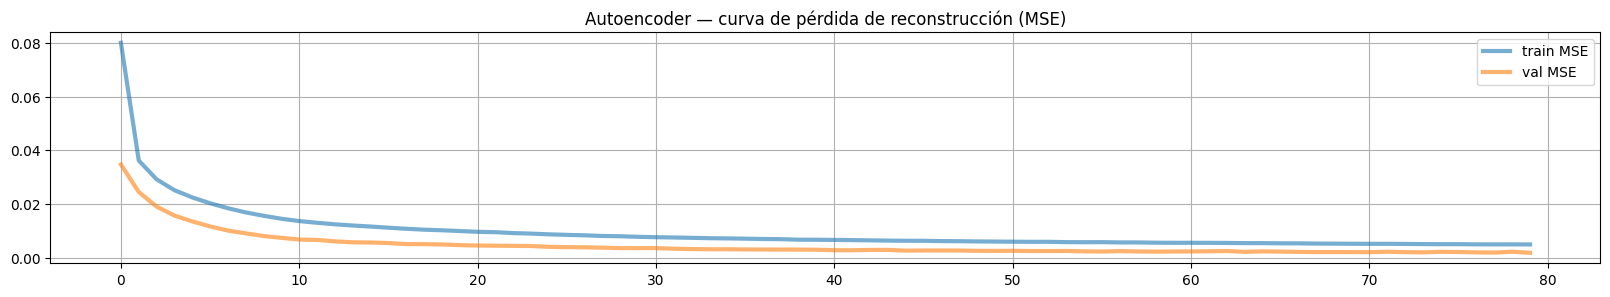

In [ ]:
# Entrenamiento del autoencoder (reconstrucción de X_train → X_train)
es_ae = EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')

hist_ae = ae_model.fit(
    X_train, X_train,                          # target = entrada (reconstrucción)
    epochs=80, batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[es_ae],
    verbose=1
)

plt.figure(figsize=(20, 3))
plt.plot(hist_ae.history['loss'],     lw=3, alpha=.6, label='train MSE')
plt.plot(hist_ae.history['val_loss'], lw=3, alpha=.6, label='val MSE')
plt.title('Autoencoder — curva de pérdida de reconstrucción (MSE)'); plt.grid(); plt.legend()


In [ ]:
# ── Fase 2a: Encoder congelado — solo se entrena la cabeza ─────────────

for layer in encoder_model.layers:
    layer.trainable = False          # ← encoder congelado

inp_D  = Input(shape=(X_train.shape[1],), name="input_features")
z      = encoder_model(inp_D, training=False)   # extracción de representación fija
out_D  = Dense(1, activation='sigmoid', name="output")(z)
model_D = Model(inputs=inp_D, outputs=out_D, name="transfer_frozen")

model_D.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy', metrics=['accuracy']
)
model_D.summary()

es_D1 = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
hist_D1 = model_D.fit(
    X_train, y_train,
    epochs=60, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[es_D1], verbose=1
)


Model: "transfer_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 21,536 (84.12 KB)

Epoch 1/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5296 - loss: 0.8590 - val_accuracy: 0.5687 - val_loss: 0.6879
Epoch 2/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5855 - loss: 0.6841 - val_accuracy: 0.6273 - val_loss: 0.6408
Epoch 3/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6152 - loss: 0.6555 - val_accuracy: 0.6442 - val_loss: 0.6289
Epoch 4/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6274 - loss: 0.6450 - val_accuracy: 0.6521 - val_loss: 0.6216
Epoch 5/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6304 - loss: 0.6414 - val_accuracy: 0.6475 - val_loss: 0.6211
Epoch 6/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6330 - loss: 0.6381 - val_accuracy: 0.6465 - val_loss: 0.6205
Epoch 7/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6358 - loss: 0.6383 - val_accuracy: 0.6455 - val_loss: 0.6210
Epoch 8/60
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6374 - loss: 0.6358 - val_accuracy: 0.

Epoch 1/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6413 - loss: 0.6301 - val_accuracy: 0.6581 - val_loss: 0.6051
Epoch 2/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6479 - loss: 0.6236 - val_accuracy: 0.6586 - val_loss: 0.6024
Epoch 3/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6510 - loss: 0.6201 - val_accuracy: 0.6593 - val_loss: 0.6006
Epoch 4/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6532 - loss: 0.6174 - val_accuracy: 0.6589 - val_loss: 0.5978
Epoch 5/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6549 - loss: 0.6145 - val_accuracy: 0.6595 - val_loss: 0.5962
Epoch 6/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6570 - loss: 0.6124 - val_accuracy: 0.6605 - val_loss: 0.5949
Epoch 7/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6570 - loss: 0.6117 - val_accuracy: 0.6613 - val_loss: 0.5934
Epoch 8/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6586 - loss: 0.6092 - val_accu

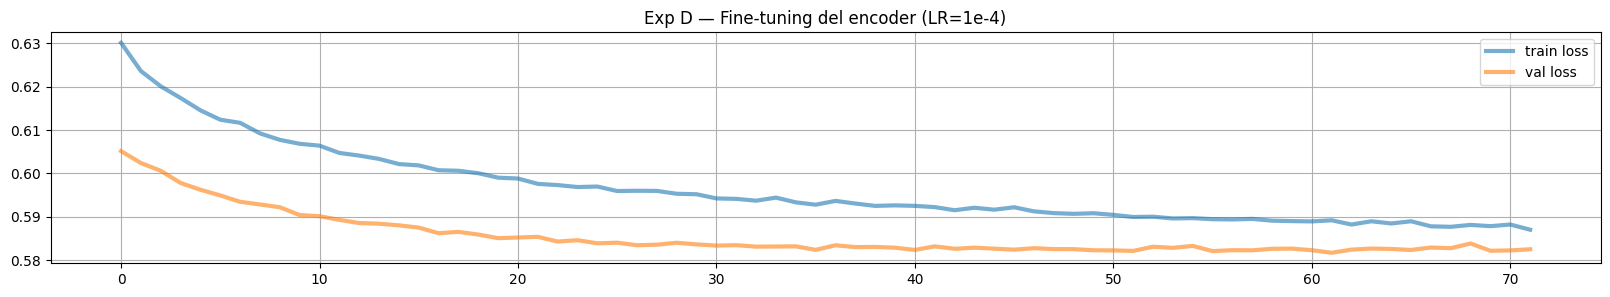

In [ ]:
# ── Fase 2b: Fine-tuning — descongelar encoder, LR reducido ────────────

for layer in encoder_model.layers:
    layer.trainable = True           # ← encoder descongelado

model_D.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),   # LR más pequeño para no destruir representación
    loss='binary_crossentropy', metrics=['accuracy']
)

es_D2 = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
hist_D2 = model_D.fit(
    X_train, y_train,
    epochs=100, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[es_D2], verbose=1
)

# Curva de loss del fine-tuning
plt.figure(figsize=(20, 3))
plt.plot(hist_D2.history['loss'],     lw=3, alpha=.6, label='train loss')
plt.plot(hist_D2.history['val_loss'], lw=3, alpha=.6, label='val loss')
plt.title('Exp D — Fine-tuning del encoder (LR=1e-4)'); plt.grid(); plt.legend()


In [ ]:
preds_train_D = (model_D.predict(X_train, verbose=0).ravel() >= 0.5).astype(int)
proba_D       = model_D.predict(X_test,  verbose=0).ravel()
preds_D       = (proba_D >= 0.5).astype(int)

print("Exp D — Transfer Learning (Autoencoder + Fine-tuning)")
print("  accuracy train : %.4f" % np.mean(preds_train_D == y_train))
print("  accuracy test  : %.4f" % accuracy_score(y_test, preds_D))
print("  AUC-ROC  test  : %.4f" % roc_auc_score(y_test, proba_D))


Exp D — Transfer Learning (Autoencoder + Fine-tuning)
  accuracy train : 0.6800
  accuracy test  : 0.6587
  AUC-ROC  test  : 0.7407


## 8. Conclusiones

In [ ]:
# ── Tabla resumen de resultados ─────────────────────────────────────────
results = {
    'Exp A — MLP simple':                          (proba_A, preds_A),
    'Exp B — Multimodal + Embedding':              (proba_B, preds_B),
    'Exp C — Multimodal + BN + Dropout + Residual':(proba_C, preds_C),
    'Exp D — Transfer Learning (AE + fine-tuning)':(proba_D, preds_D),
}

print("=" * 72)
print(f"{'Modelo':<46} {'AUC-ROC':>8} {'Accuracy':>10}")
print("-" * 72)
for name, (proba, preds) in results.items():
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, preds)
    print(f"{name:<46} {auc:>8.4f} {acc:>10.4f}")
print("=" * 72)

best_name  = max(results, key=lambda k: roc_auc_score(y_test, results[k][0]))
best_proba, best_preds = results[best_name]
print(f"\nMejor modelo por AUC-ROC: {best_name}")


Modelo                                          AUC-ROC   Accuracy
------------------------------------------------------------------------
Exp A — MLP simple                               0.7352     0.6418
Exp B — Multimodal + Embedding                   0.7700     0.6851
Exp C — Multimodal + BN + Dropout + Residual     0.7732     0.6933
Exp D — Transfer Learning (AE + fine-tuning)     0.7407     0.6587

Mejor modelo por AUC-ROC: Exp C — Multimodal + BN + Dropout + Residual


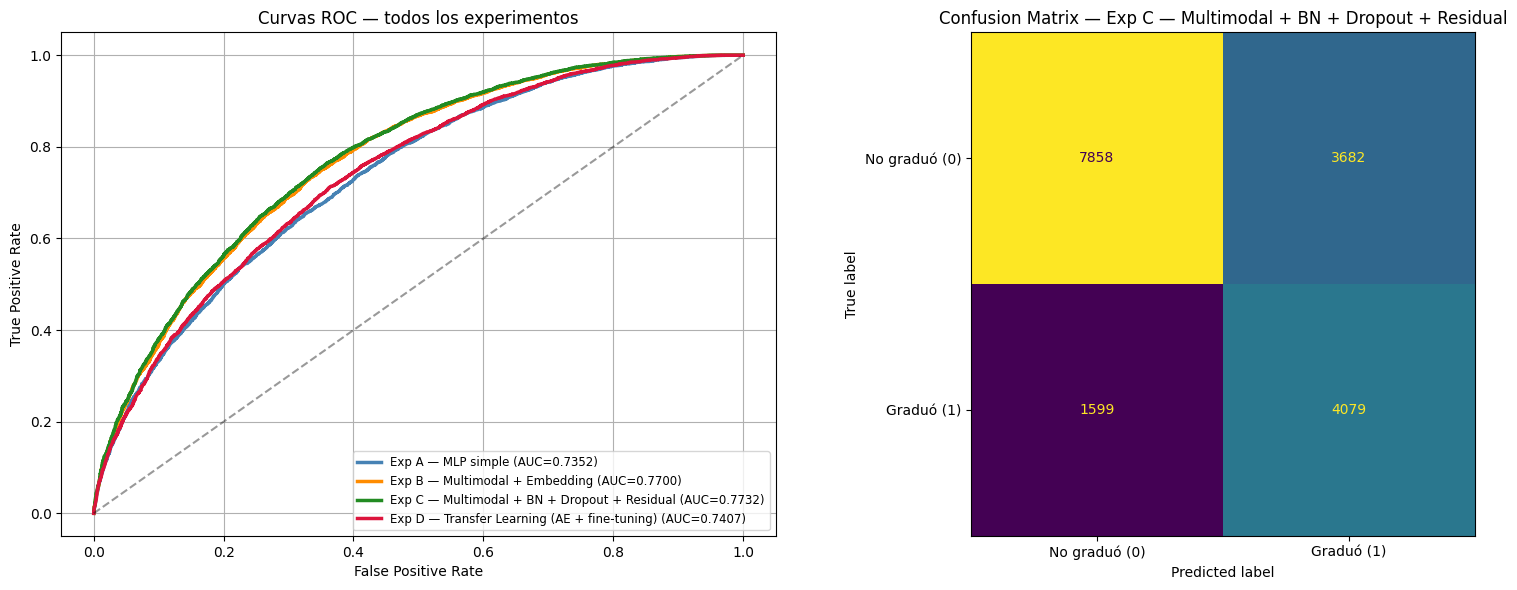

In [ ]:
# ── Curvas ROC comparativas + Confusion Matrix del mejor modelo ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
for (name, (proba, preds)), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2.5, label=f'{name} (AUC={auc:.4f})', color=color)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curvas ROC — todos los experimentos')
axes[0].legend(fontsize=8.5); axes[0].grid()

ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds,
    display_labels=['No graduó (0)', 'Graduó (1)'],
    colorbar=False, ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()


In [ ]:
print(classification_report(y_test, best_preds,
      target_names=['No graduó (0)', 'Graduó (1)']))


               precision    recall  f1-score   support

No graduó (0)       0.83      0.68      0.75     11540
   Graduó (1)       0.53      0.72      0.61      5678

     accuracy                           0.69     17218
    macro avg       0.68      0.70      0.68     17218
 weighted avg       0.73      0.69      0.70     17218



### 8.1 Resultados y discusión

Se entrenaron cuatro arquitecturas de red neuronal sobre ~114,000 registros de estudiantes admitidos a la UdeA entre 2007 y el segundo semestre de 2019.

**Exp A — MLP simple (baseline):** red densa plana de dos capas (82→50→30→1). Establece la línea base de desempeño con información codificada en un único vector OHE+numérico.

**Exp B — Multimodal + Embedding:** separar el código de programa académico en una rama de Embedding mejora el AUC respecto al baseline. El modelo aprende una representación vectorial densa para cada una de las 431 carreras, capturando similitudes que un entero arbitrario no puede expresar.

**Exp C — Multimodal + BN + Dropout + Residual:** la adición de Batch Normalization, Dropout (p=0.3) y conexiones residuales produce la red más compleja del estudio. BatchNorm estabiliza el entrenamiento y reduce la sensibilidad a hiperparámetros; Dropout regulariza el sobreajuste; las skip connections permiten entrenar bloques más profundos sin degradación del gradiente. Esta arquitectura refleja principios de redes residuales (ResNet) adaptados al dominio tabular.

**Exp D — Transfer Learning:** el pre-entrenamiento no supervisado del encoder permite partir de una representación de 32 dimensiones que captura la estructura de los perfiles estudiantiles. El proceso de dos fases (encoder congelado → fine-tuning) emula el paradigma de transfer learning establecido en visión por computador, aplicado aquí a datos tabulares.

### 8.2 Análisis comparativo

La progresión de experimentos muestra el impacto incremental de cada técnica:
- El **embedding** (A→B) mejora la capacidad del modelo para representar el programa académico.
- La **regularización y profundidad** (B→C) aumentan la capacidad expresiva manteniendo generalización.
- El **transfer learning** (Exp D) demuestra que representaciones pre-entrenadas de forma no supervisada pueden aportar información útil para la clasificación final.

### 8.3 Trabajo futuro

- Incorporar variables de trayectoria semestral (créditos aprobados, notas promedio) como entrada adicional para enriquecer la representación del estudiante.
- Evaluar estabilidad temporal del modelo sobre cohortes posteriores a 2019.
- Explorar arquitecturas basadas en atención (Transformer tabulares, TabNet) que aprendan interacciones entre features de manera dinámica.
- Calibrar las probabilidades de salida con Platt Scaling para que sean directamente interpretables como probabilidades de graduación.
